# Project Part 3 — Channel Coding
## Audio Source (8-bit quantization)


In [1]:
import math, random, collections, wave, struct, heapq
import matplotlib.pyplot as plt

def read_wav(f):
    with wave.open(f,'rb') as wf:
        nc=wf.getnchannels();sw=wf.getsampwidth();nf=wf.getnframes()
        rb=wf.readframes(nf);fr=wf.getframerate()
    fmt='<'+str(nf*nc)+('h' if sw==2 else 'b')
    s=list(struct.unpack(fmt,rb))
    return (s[::2] if nc==2 else s), fr

def quantize(samples,n_bits):
    n_lvl=2**n_bits
    return [max(0,min(n_lvl-1,int((s+32768)/65535*(n_lvl-1)))) for s in samples]

raw_samples, framerate = read_wav('Audio.wav')
symbols = quantize(raw_samples, 8)
n = len(symbols)
probs = {x:c/n for x,c in collections.Counter(symbols).items()}

def entropy(p): return -sum(v*math.log2(v) for v in p.values() if v>0)

# Build Huffman and compress
def build_huffman(prob_dict):
    heap=[[p,i,sym,None,None] for i,(sym,p) in enumerate(prob_dict.items())]
    heapq.heapify(heap);nid=len(prob_dict)
    while len(heap)>1:
        l=heapq.heappop(heap);r=heapq.heappop(heap)
        heapq.heappush(heap,[l[0]+r[0],nid,None,l,r]);nid+=1
    return heap[0]

def get_codes(tree,prefix='',codes={}):
    if tree[2] is not None:codes[tree[2]]=prefix or '0'
    else:get_codes(tree[3],prefix+'0',codes);get_codes(tree[4],prefix+'1',codes)
    return codes

tree  = build_huffman(probs)
codes = get_codes(tree,'',{})
rev   = {v:k for k,v in codes.items()}

sample_symbols = symbols[:5000]
compressed_bits = [int(b) for s in sample_symbols for b in codes[s]]

H = entropy(probs)
print(f'Samples compressed  : {len(sample_symbols)}')
print(f'Compressed bits     : {len(compressed_bits)}')
print(f'Bits/sample         : {len(compressed_bits)/len(sample_symbols):.4f}')
print(f'H(X)                : {H:.4f}')

Samples compressed  : 5000
Compressed bits     : 20000
Bits/sample         : 4.0000
H(X)                : 6.1619


---
## Task 1 — Binary Symmetric Channel
### Q1a-b: BSC implementation and bit error measurement

In [2]:
def bsc(bits,p,seed=42):
    rng=random.Random(seed)
    return [b^(1 if rng.random()<p else 0) for b in bits]

def bits_to_symbols(bits, rev_codes):
    decoded, buf = [], ''
    for bit in bits:
        buf+=str(bit)
        if buf in rev_codes: decoded.append(rev_codes[buf]);buf=''
        if len(buf)>30: buf=''
    return decoded

print('BSC effect on compressed audio (no channel coding):')
for p in [1e-3, 1e-2, 5e-2]:
    noisy = bsc(compressed_bits,p)
    ber   = sum(a!=b for a,b in zip(compressed_bits,noisy))/len(compressed_bits)
    dec   = bits_to_symbols(noisy,rev)
    ml    = min(len(dec),len(sample_symbols))
    ser   = sum(a!=b for a,b in zip(dec[:ml],sample_symbols[:ml]))/max(ml,1)
    print(f'  p={p:.0e}: BER={ber:.4f}, SER={ser:.4f}')

BSC effect on compressed audio (no channel coding):
  p=1e-03: BER=0.0014, SER=0.4709
  p=1e-02: BER=0.0101, SER=0.4877
  p=5e-02: BER=0.0475, SER=0.6529


### Q1c: Audio quality after BSC — reconstruct and compare

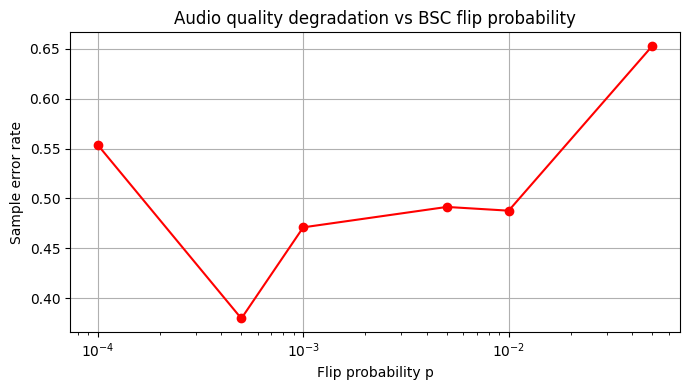

Even small p causes severe distortion in audio — compressed data is fragile!


In [3]:
# We measure how well the audio is reconstructed by computing
# the fraction of correctly recovered samples

p_vals = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]
sers_no = []
for p in p_vals:
    noisy = bsc(compressed_bits,p)
    dec = bits_to_symbols(noisy,rev)
    ml = min(len(dec),len(sample_symbols))
    ser = sum(a!=b for a,b in zip(dec[:ml],sample_symbols[:ml]))/max(ml,1)
    sers_no.append(ser)

plt.figure(figsize=(7,4))
plt.semilogx(p_vals, sers_no, marker='o', color='red')
plt.xlabel('Flip probability p'); plt.ylabel('Sample error rate')
plt.title('Audio quality degradation vs BSC flip probability')
plt.grid(True); plt.tight_layout()
plt.savefig('audio_bsc_no_coding.png',dpi=100); plt.show()
print('Even small p causes severe distortion in audio — compressed data is fragile!')

---
## Task 2 — Repetition Coding
### Q2a-b: Encode, transmit through BSC, decode with majority voting

In [4]:
def repeat_encode(bits,r): return [b for b in bits for _ in range(r)]
def repeat_decode(bits,r):
    return [1 if sum(bits[i:i+r])>r//2 else 0 for i in range(0,len(bits)-r+1,r)]

p = 0.01
print(f'Repetition coding (audio, p={p}):')
for r in [3, 5, 7]:
    enc   = repeat_encode(compressed_bits,r)
    noisy = bsc(enc,p)
    db    = repeat_decode(noisy,r)
    ml    = min(len(db),len(compressed_bits))
    ber   = sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1)
    dec   = bits_to_symbols(db,rev)
    ml2   = min(len(dec),len(sample_symbols))
    ser   = sum(a!=b for a,b in zip(dec[:ml2],sample_symbols[:ml2]))/max(ml2,1)
    print(f'  r={r}: BER_out={ber:.6f}, SER={ser:.4f}, rate={1/r:.3f}')

Repetition coding (audio, p=0.01):
  r=3: BER_out=0.000250, SER=0.2243, rate=0.333
  r=5: BER_out=0.000000, SER=0.0000, rate=0.200
  r=7: BER_out=0.000000, SER=0.0000, rate=0.143


---
## Task 3 — Hamming(7,4) Coding
### Q3a-b: Implement, encode, transmit, decode

In [5]:
def hamming_encode_nibble(d):
    d1,d2,d3,d4=d
    return [d1^d2^d4, d1^d3^d4, d1, d2^d3^d4, d2, d3, d4]

def hamming_decode_nibble(c):
    p1,p2,d1,p3,d2,d3,d4=c
    s1=p1^d1^d2^d4; s2=p2^d1^d3^d4; s3=p3^d2^d3^d4
    syn=s1+2*s2+4*s3
    bits=list(c)
    if syn!=0: bits[syn-1]^=1
    return [bits[2],bits[4],bits[5],bits[6]]

def hamming_encode(bits):
    padded=bits+[0]*((4-len(bits)%4)%4)
    enc=[]
    for i in range(0,len(padded),4): enc.extend(hamming_encode_nibble(padded[i:i+4]))
    return enc

def hamming_decode(bits):
    dec=[]
    for i in range(0,len(bits)-6,7): dec.extend(hamming_decode_nibble(bits[i:i+7]))
    return dec

p = 0.01
enc   = hamming_encode(compressed_bits)
noisy = bsc(enc,p)
db    = hamming_decode(noisy)
ml    = min(len(db),len(compressed_bits))
ber   = sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1)
dec   = bits_to_symbols(db,rev)
ml2   = min(len(dec),len(sample_symbols))
ser   = sum(a!=b for a,b in zip(dec[:ml2],sample_symbols[:ml2]))/max(ml2,1)
print(f'Hamming(7,4) at p={p}:')
print(f'  BER after decoding : {ber:.6f}')
print(f'  Sample error rate  : {ser:.4f}')
print(f'  Effective rate     : {4/7:.3f} bits/channel_bit')

Hamming(7,4) at p=0.01:
  BER after decoding : 0.000950
  Sample error rate  : 0.7209
  Effective rate     : 0.571 bits/channel_bit


---
## Task 4 — Full Comparison
### Q4a: Table and plot

In [6]:
p = 0.01
print(f'=== Channel Coding Comparison (audio 8-bit, p={p}) ===')
print(f'{"Scheme":<25} {"Rate":>8} {"BER out":>12} {"SER":>10}')
print('-'*60)

# No coding
noisy=bsc(compressed_bits,p);ber_nc=sum(a!=b for a,b in zip(compressed_bits,noisy))/len(compressed_bits)
dec=bits_to_symbols(noisy,rev);ml=min(len(dec),len(sample_symbols))
ser_nc=sum(a!=b for a,b in zip(dec[:ml],sample_symbols[:ml]))/max(ml,1)
print(f'{"No coding":<25} {"1.000":>8} {ber_nc:>12.6f} {ser_nc:>10.4f}')

for r in [3,5,7]:
    enc=repeat_encode(compressed_bits,r);noisy=bsc(enc,p);db=repeat_decode(noisy,r)
    ml=min(len(db),len(compressed_bits))
    ber=sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1)
    dec=bits_to_symbols(db,rev);ml2=min(len(dec),len(sample_symbols))
    ser=sum(a!=b for a,b in zip(dec[:ml2],sample_symbols[:ml2]))/max(ml2,1)
    print(f'{f"Repetition r={r}":<25} {1/r:>8.3f} {ber:>12.6f} {ser:>10.4f}')

enc=hamming_encode(compressed_bits);noisy=bsc(enc,p);db=hamming_decode(noisy)
ml=min(len(db),len(compressed_bits))
ber=sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1)
dec=bits_to_symbols(db,rev);ml2=min(len(dec),len(sample_symbols))
ser=sum(a!=b for a,b in zip(dec[:ml2],sample_symbols[:ml2]))/max(ml2,1)
print(f'{"Hamming(7,4)":<25} {4/7:>8.3f} {ber:>12.6f} {ser:>10.4f}')

=== Channel Coding Comparison (audio 8-bit, p=0.01) ===
Scheme                        Rate      BER out        SER
------------------------------------------------------------
No coding                    1.000     0.010100     0.4877
Repetition r=3               0.333     0.000250     0.2243
Repetition r=5               0.200     0.000000     0.0000
Repetition r=7               0.143     0.000000     0.0000
Hamming(7,4)                 0.571     0.000950     0.7209


### Q4b: BER vs p — all schemes

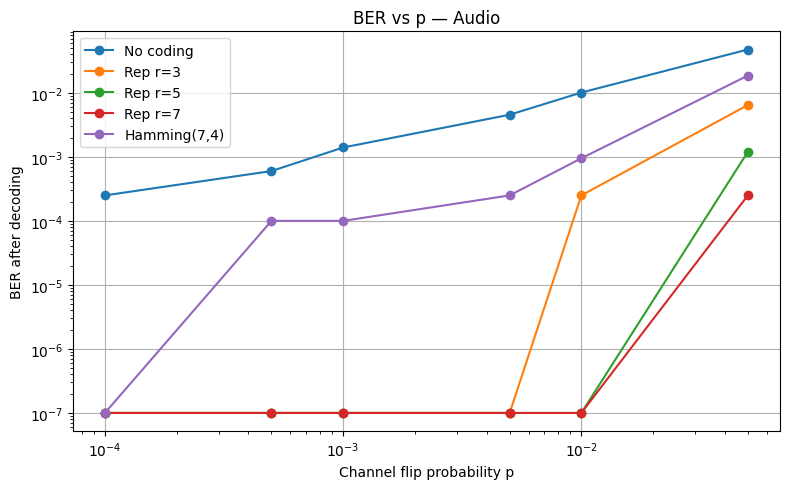

In [7]:
p_vals=[1e-4,5e-4,1e-3,5e-3,1e-2,5e-2]
bers_no,bers_r3,bers_r5,bers_r7,bers_ham=[],[],[],[],[]

for p in p_vals:
    noisy=bsc(compressed_bits,p)
    bers_no.append(sum(a!=b for a,b in zip(compressed_bits,noisy))/len(compressed_bits))
    for r,lst in [(3,bers_r3),(5,bers_r5),(7,bers_r7)]:
        enc=repeat_encode(compressed_bits,r);noisy=bsc(enc,p);db=repeat_decode(noisy,r)
        ml=min(len(db),len(compressed_bits))
        lst.append(sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1))
    enc=hamming_encode(compressed_bits);noisy=bsc(enc,p);db=hamming_decode(noisy)
    ml=min(len(db),len(compressed_bits))
    bers_ham.append(sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1))

plt.figure(figsize=(8,5))
for label,data in [('No coding',bers_no),('Rep r=3',bers_r3),
                    ('Rep r=5',bers_r5),('Rep r=7',bers_r7),('Hamming(7,4)',bers_ham)]:
    plt.loglog(p_vals,[max(d,1e-7) for d in data],marker='o',label=label)
plt.xlabel('Channel flip probability p'); plt.ylabel('BER after decoding')
plt.title('BER vs p — Audio'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('audio_ber_vs_p.png',dpi=100); plt.show()